In [1]:
from modules import *

In [2]:
import sys
from pathlib import Path

root = Path.cwd().parent          # assignment/
sys.path.insert(0, str(root))

from data_utils import *          # data_utils.py in the root

In [3]:
data = load_memmap_dataset('/Users/anubhav/Desktop/Courses/Fall 26/Assignments/NLP/assignment_2/data/tinystories_valid.bin', '/Users/anubhav/Desktop/Courses/Fall 26/Assignments/NLP/assignment_2/data/tinystories_valid.meta')
vocab, merges = load_vocab("/Users/anubhav/Desktop/Courses/Fall 26/Assignments/NLP/assignment_2/data/tinystories_vocab_merges.pt")

In [4]:
params = {
    "VOCAB_SIZE": 10_000,
    "CONTEXT_LENGTH": 128,
    "D_MODEL": 128,
    "NUM_LAYERS": 4,
    "NUM_HEADS": 4,
    "D_FF": 384,
    "ROPE_THETA": 10000.0,
    "DEVICE": "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu",
    
    "BATCH_SIZE": 32,
    "MAX_LR": 1e-3,
    "MIN_LR": 1e-4,
    "WARMUP_ITERS": 100,
    "TOTAL_STEPS": 500,
    "WEIGHT_DECAY": 0.01,
    "MAX_GRAD_NORM": 1.0
}

for k,v in params.items():
    print(f"{k}: {v}")

VOCAB_SIZE: 10000
CONTEXT_LENGTH: 128
D_MODEL: 128
NUM_LAYERS: 4
NUM_HEADS: 4
D_FF: 384
ROPE_THETA: 10000.0
DEVICE: mps
BATCH_SIZE: 32
MAX_LR: 0.001
MIN_LR: 0.0001
WARMUP_ITERS: 100
TOTAL_STEPS: 500
WEIGHT_DECAY: 0.01
MAX_GRAD_NORM: 1.0


In [5]:
MyGPT = TransformerLM(
    vocab_size=params["VOCAB_SIZE"],
    context_length=params["CONTEXT_LENGTH"],
    d_model=params["D_MODEL"],
    num_layers=params["NUM_LAYERS"],
    num_heads=params["NUM_HEADS"],
    d_ff=params["D_FF"],
    rope_theta=params["ROPE_THETA"],
    device=params["DEVICE"]
)

MyOptimizer = AdamW(params=MyGPT.parameters())

In [6]:
losses = []
MyGPT.train()
for step in range(params['TOTAL_STEPS']):
    # 1. set the scheduled lr
    lr = get_lr_cosine_schedule(
        it=step,
        max_learning_rate=params['MAX_LR'],
        min_learning_rate=params['MIN_LR'],
        warmup_iters=params['WARMUP_ITERS'],
        cosine_cycle_iters=params['TOTAL_STEPS']
    )
    for group in MyOptimizer.param_groups:
        group["lr"] = lr

    # 2. sample a batch
    x, y = get_batch(data, params['BATCH_SIZE'], params['CONTEXT_LENGTH'], params['DEVICE'])

    # 3. forward, loss, backward
    logits = MyGPT(x)                      # (batch, seq, vocab)
    loss = cross_entropy(inputs=logits, targets=y)        # your version handles the extra dim
    MyOptimizer.zero_grad()
    loss.backward()

    # 4. clip, then step
    gradient_clipping(parameters=MyGPT.parameters(), max_l2_norm=params['MAX_GRAD_NORM'])
    MyOptimizer.step()

    losses.append(loss.item())
    if step % 50 == 0:
        print(f"step {step:5d} | loss {loss.item():.4f} | lr {lr:.2e}")

step     0 | loss 9.2205 | lr 0.00e+00
step    50 | loss 7.1345 | lr 5.00e-04
step   100 | loss 5.2480 | lr 1.00e-03
step   150 | loss 4.3795 | lr 9.66e-04
step   200 | loss 3.9361 | lr 8.68e-04
step   250 | loss 3.5385 | lr 7.22e-04
step   300 | loss 3.4725 | lr 5.50e-04
step   350 | loss 3.4306 | lr 3.78e-04
step   400 | loss 3.4316 | lr 2.32e-04
step   450 | loss 3.2537 | lr 1.34e-04


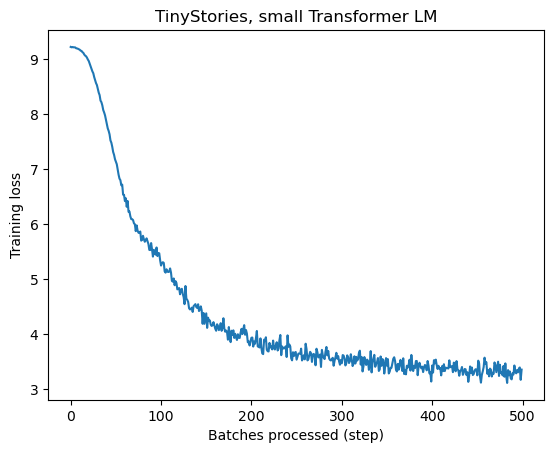

In [7]:
import matplotlib.pyplot as plt

plt.plot(losses)
plt.xlabel("Batches processed (step)")
plt.ylabel("Training loss")
plt.title("TinyStories, small Transformer LM")
plt.show()

In [14]:
print(decode(x[0].tolist(), vocab))

 cake. The cake was on a table in the park. Ben was very excite.
Ben wanted to eat the cake. He jumped up and down. He barked at the cake. His friends saw the cake too. They all wanted to eat it. They all felt excite.
Ben and his friends made a plan. They would get the cake and share it. They jumped on the table and ate the cake. It was so yummy! They were all very happy and excite. And they played together all day long.

One day, a girl named Amy had a pretty folder. She liked to look at the folder and admire


In [15]:
print(decode(y[0].tolist(), vocab))

. The cake was on a table in the park. Ben was very excite.
Ben wanted to eat the cake. He jumped up and down. He barked at the cake. His friends saw the cake too. They all wanted to eat it. They all felt excite.
Ben and his friends made a plan. They would get the cake and share it. They jumped on the table and ate the cake. It was so yummy! They were all very happy and excite. And they played together all day long.

One day, a girl named Amy had a pretty folder. She liked to look at the folder and admire it


In [16]:
@torch.no_grad()
def generate_output(model, prompt_ids, max_new_tokens=60):
    model.eval()
    ids = torch.tensor([prompt_ids], device=params['DEVICE'])
    for _ in range(max_new_tokens):
        logits = model(ids[:, -params['CONTEXT_LENGTH']:])[:, -1, :]
        next_id = logits.argmax(dim=-1, keepdim=True)    # greedy
        ids = torch.cat([ids, next_id], dim=1)
    return ids[0].tolist()

prompt = data[:10].tolist()          # .tolist() gives plain ints, not np.int64
print(decode(generate(MyGPT, prompt), vocab))

u don't have to be scared of the loud.

Once upon a time, there was a little girl named Lily. She loved to play with his friends. One day, she saw a big, big tree with a big tree. She was very happy.
One day, a little girl named Lily went to the park. She saw
